# Figures from Akins and Hofstadter 2026
## 1. ECCM atmosphere run + spectrum 

### Imports 

In [1]:
import os 
import numpy as np 
import scipy.constants as spc
import matplotlib.pyplot as plt 
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as colors

from eccm_mrtm import eccm, mrtm 
module_dir = eccm.__path__[0]
plt.style.use('../eccm.mplstyle')


## Saturn

Generating a model for Saturn, starting with a Cassini radio occultation profile and assuming deep abundances corresponding to 10x enrichment for O, C, S, and 3x for N, 70% (Laraia)

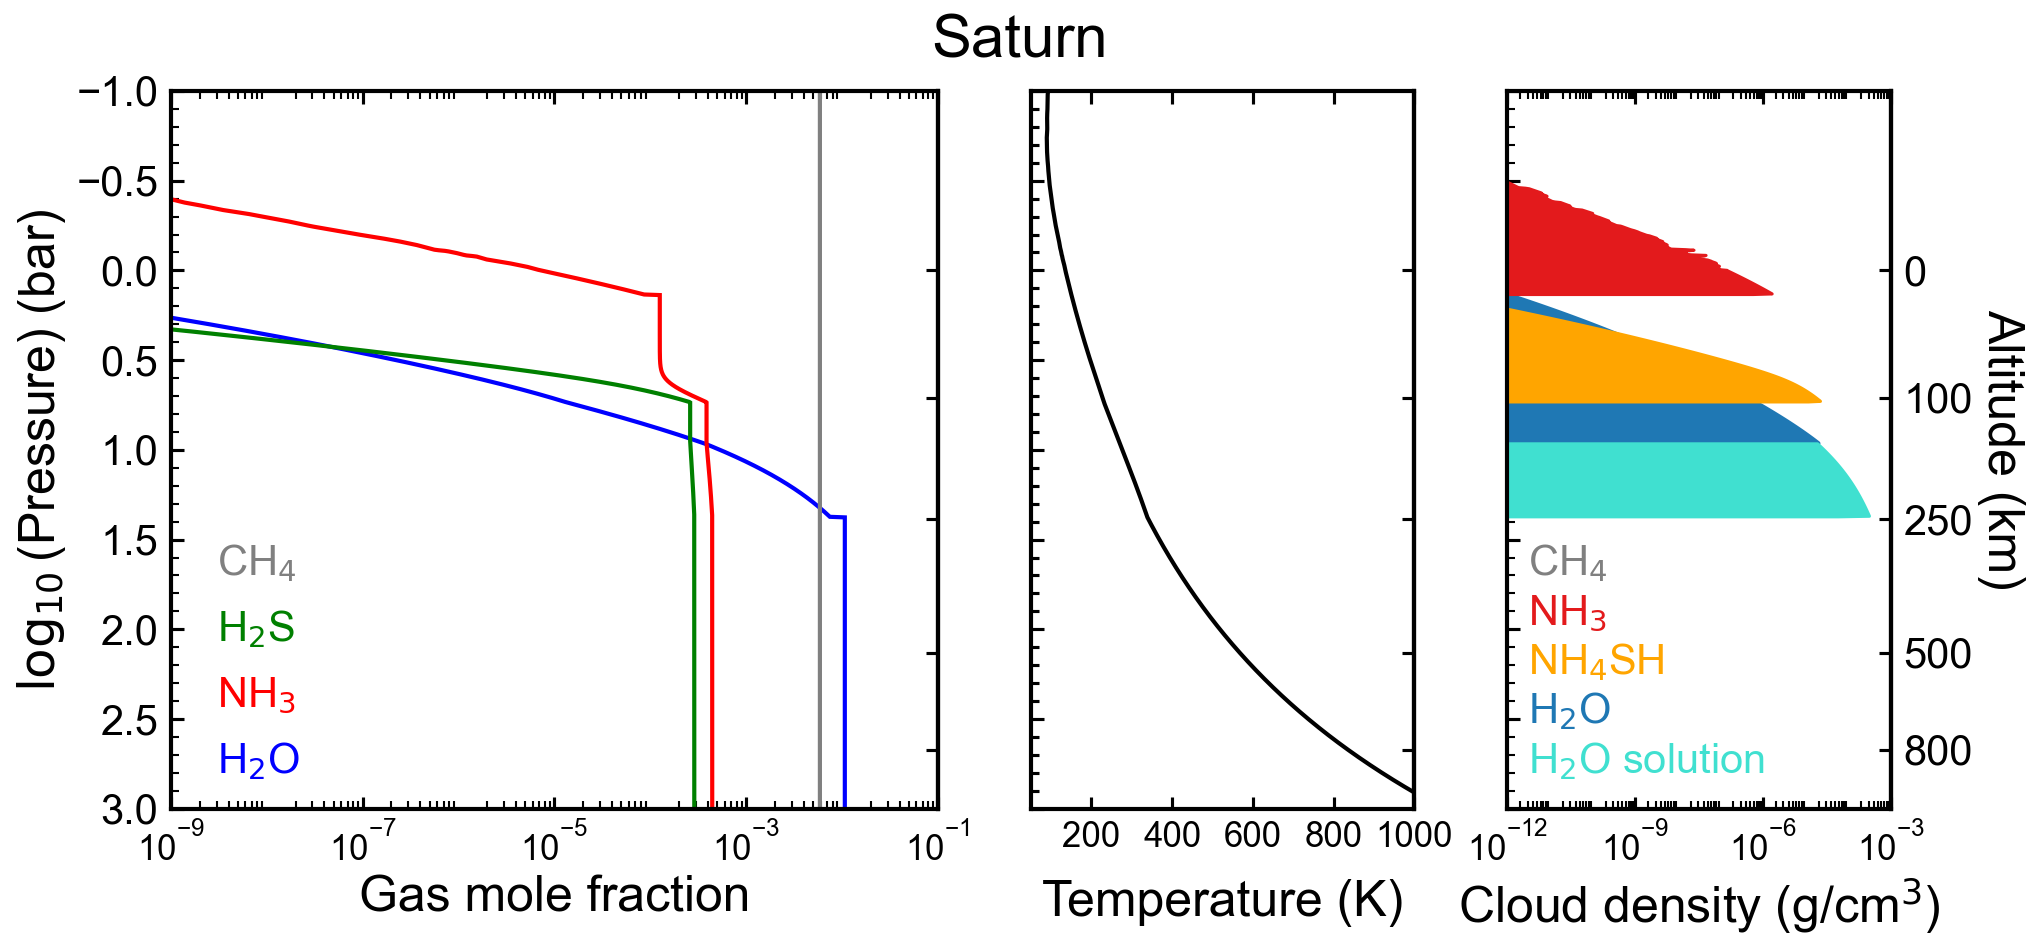

In [30]:
p_grid = np.logspace(2, 10, 2500)  # Pa 
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # Saturn

# Load RO profile 
data_dir = eccm.__path__[0]
saturn_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/saturn_cassini_schinder2011.txt'), skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

gases1 = eccm.solar_concentration() 

gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid'] * 1e-6
a_h2oliquid = result['aerosol_densities']['H2O']['liquid'] * 1e-6
a_nh3solid = result['aerosol_densities']['NH3']['solid'] * 1e-6
a_nh3liquid = result['aerosol_densities']['NH3']['liquid'] * 1e-6
a_h2ssolid = result['aerosol_densities']['H2S']['solid'] * 1e-6
a_h2sliquid = result['aerosol_densities']['H2S']['liquid'] * 1e-6
a_ch4solid = result['aerosol_densities']['CH4']['solid'] * 1e-6
a_ch4liquid = result['aerosol_densities']['CH4']['liquid'] * 1e-6
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid'] * 1e-6
a_nh4sh = result['aerosol_densities']['NH4SH']['solid'] * 1e-6

def p_to_z(x):
    return np.interp(x, np.log10(pressure_grid / spc.bar)[::-1], altitude_grid[::-1])

def z_to_p(x): 
    return np.interp(x, altitude_grid[::-1], np.log10(pressure_grid / spc.bar)[::-1])


gs = GridSpec(1, 3, width_ratios=[2, 1, 1], height_ratios=[1])


fig = plt.figure(figsize=(14, 7)) 
ax = fig.add_subplot(gs[1]) 
ax.plot(temperature_grid, np.log10(pressure_grid / spc.bar), color='k')
ax.set_xlabel('Temperature (K)', labelpad=12)
ax.set_ylim(-1, 3)
ax.set_xlim(50, 1000)
ax.invert_yaxis()
ax.set_xticks([200, 400, 600, 800, 1000])
ax.tick_params(axis='x', which='major', labelsize='small')
ax.tick_params(axis='x', which='minor', bottom=False, top=False)
ax.tick_params(right=False, which='both')
ax.yaxis.set_tick_params(labelcolor='none')


secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.yaxis.set_tick_params(labelcolor='none')

ax = fig.add_subplot(gs[0]) 
ax.plot(x_h2o, np.log10(pressure_grid / spc.bar), label='H$_2$O', color='b')
ax.plot(x_nh3, np.log10(pressure_grid / spc.bar), label='NH$_3$', color='r')
ax.plot(x_h2s, np.log10(pressure_grid / spc.bar), label='H$_2$S', color='g')
ax.plot(x_ch4, np.log10(pressure_grid / spc.bar), label='CH$_4$', color='gray')
ax.set_xlabel('Gas mole fraction')
ax.set_ylabel(r'$\log_{10}$(Pressure) (bar)')
ax.tick_params(axis='x', which='major', labelsize='small')
ax.set_xscale('log')
ax.set_xlim(1e-9, 1e-1)
ax.set_ylim(-1, 3)
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.tick_params(bottom=True, top=True, which='minor', width=1)

ax.invert_yaxis()
ax.tick_params(right=False, which='both')
secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.yaxis.set_tick_params(labelcolor='none')
sp = np.linspace(1.7, 2.8, 4)[::-1]

ax.text(3e-9, sp[0], 'H$_2$O', color='b')
ax.text(3e-9, sp[1], 'NH$_3$', color='r')
ax.text(3e-9, sp[2], 'H$_2$S', color='g')
ax.text(3e-9, sp[3], 'CH$_4$', color='gray')

paired_cmap = plt.get_cmap('Paired')

ax = fig.add_subplot(gs[2]) 
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2osolid, label='H$_2$O solid', color=paired_cmap(1))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2oliquid, label='H$_2$O liquid', color=paired_cmap(0))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2osolution, label='H$_2$O solution', color='turquoise')
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_nh3solid, label='NH$_3$ solid', color=paired_cmap(5))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_nh3liquid, label='NH$_3$ liquid', color=paired_cmap(4))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_ch4solid, label='CH$_4$ solid', color='gray')
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_ch4liquid, label='CH$_4$ liquid', color='k')
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_nh4sh, label='NH4SH', color='orange')
ax.set_xlabel('Cloud density (g/cm$^3$)')
ax.set_xscale('log')
ax.set_ylim(-1, 3)
ax.set_xlim(1e-12, 1e-3)
ax.invert_yaxis()
ax.set_xticks([1e-12, 1e-9, 1e-6, 1e-3])
ax.tick_params(right=False, which='both')
ax.yaxis.set_tick_params(labelcolor='none')
ax.tick_params(axis='x', which='major', labelsize='small')
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.tick_params(bottom=True, top=True, which='minor', width=1)
sp = np.linspace(1.7, 2.8, 5)[::-1]
ax.text(3e-12, sp[0], 'H$_2$O solution', color='turquoise')
ax.text(3e-12, sp[1], 'H$_2$O', color=paired_cmap(1))
ax.text(3e-12, sp[2], 'NH$_4$SH', color='orange')
ax.text(3e-12, sp[3], 'NH$_3$', color=paired_cmap(5))
ax.text(3e-12, sp[4], 'CH$_4$', color='gray')

secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.yaxis.set_major_formatter(ticker.ScalarFormatter())
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.set_ylabel('Altitude (km)', rotation=-90, labelpad=25) 

fig.suptitle('Saturn', y=0.92, fontsize='x-large')
fig.tight_layout(w_pad=-2) 
fig.savefig('saturn_eccm.pdf')


## Emission and angular spectrum, atmospheric weighting functions 

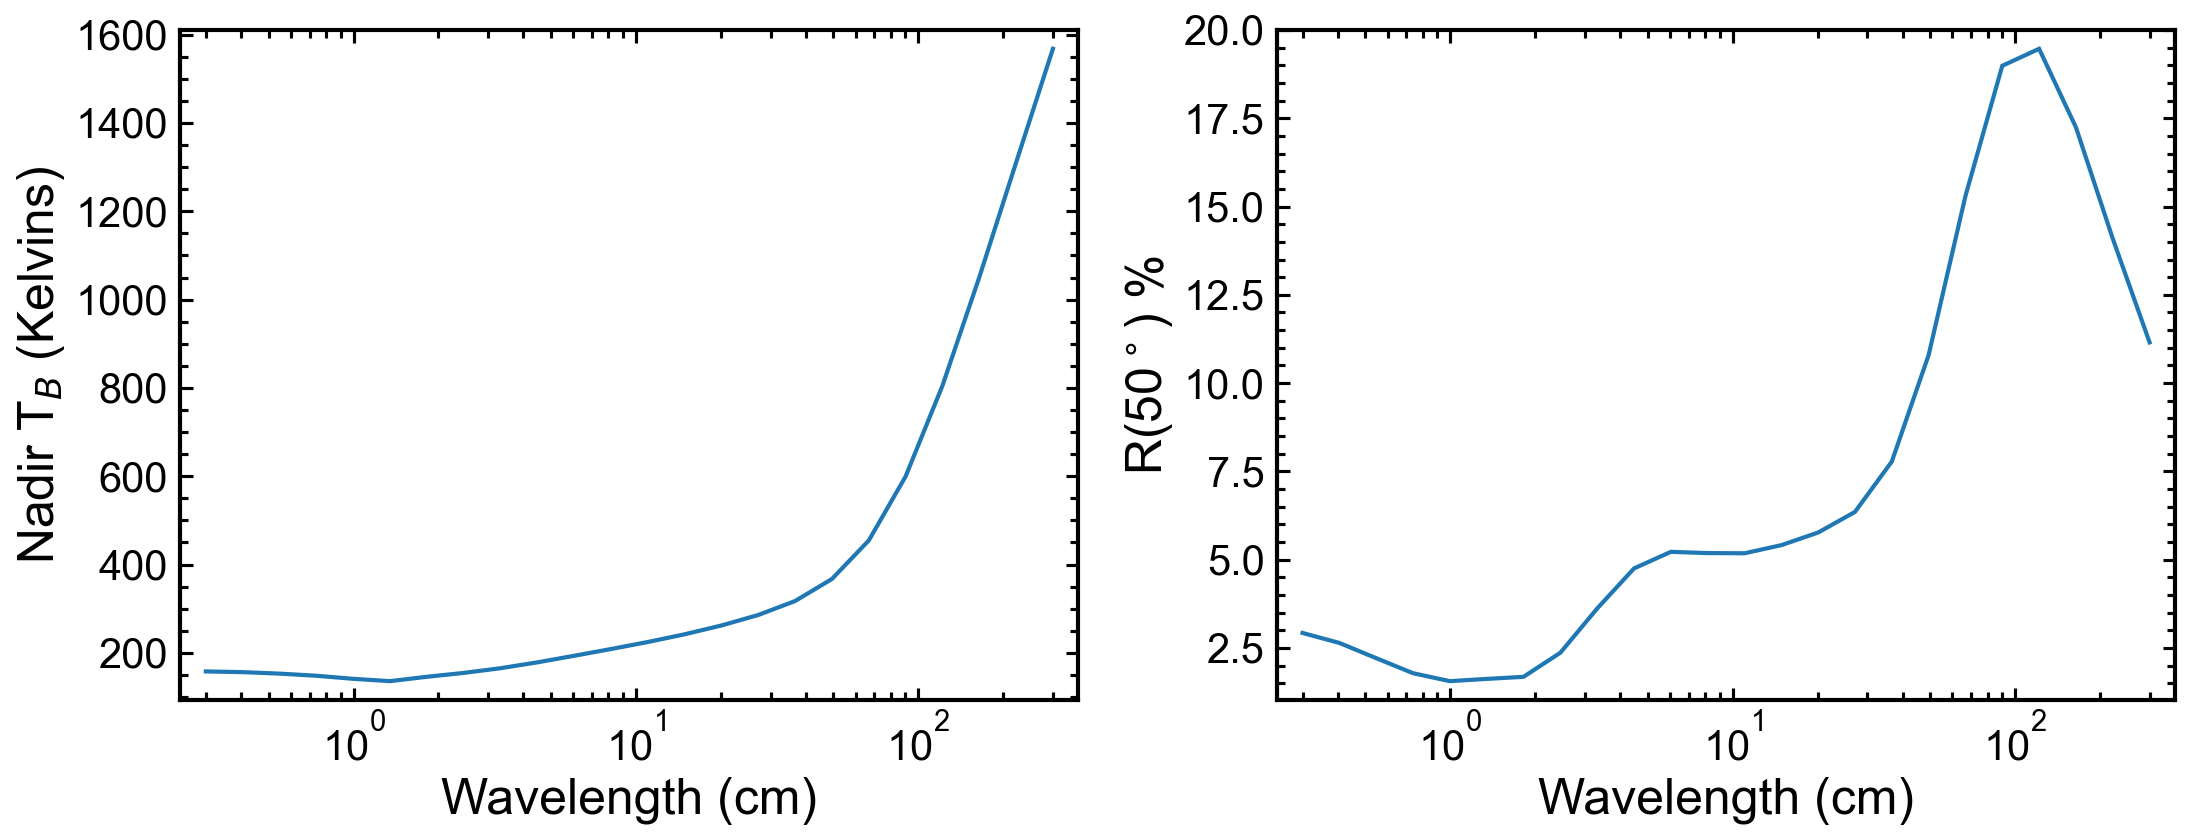

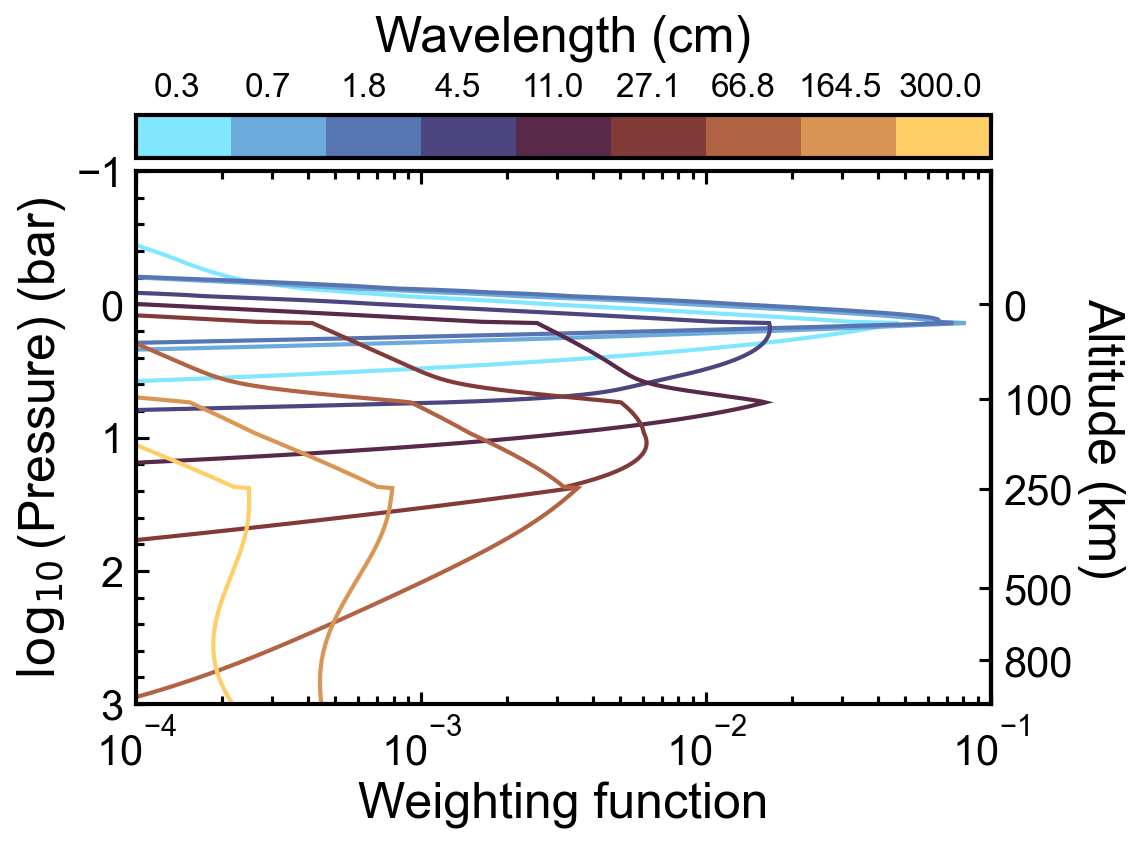

In [3]:

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
freq_ghz = spc.c / 1e9 / np.logspace(np.log10(3e-3), np.log10(3), 24)
freq_ghz = np.append(freq_ghz, spc.c / 1e9 / 3)  # Staple 3m at the end 
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1)
ax2.plot(wave_cm, R50)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('Nadir T$_B$ (Kelvins)')
ax2.set_ylabel(r'R(50$^\circ$) %')
ax1.set_xscale('log')
ax2.set_xscale('log')
fig.tight_layout()


fig = plt.figure() 
ax = fig.add_subplot(1, 1, 1) 

# Colormap setup
freqs = freq_ghz[::3]  # Only using every third frequency
waves = wave_cm[::3]
n_colors = len(waves)
cmap = plt.get_cmap('managua_r', n_colors)  # Discrete version of colormap

edges = np.concatenate([np.array([np.min(waves) - 0.01]), 
                (waves[:-1] + waves[1:]) / 2, 
                np.array([np.max(waves) + 0.01])]) 

norm = colors.BoundaryNorm(edges, ncolors=n_colors)

for i, wup in enumerate(weight_up):
    if not i % 3:
        wave = wave_cm[i]
        color = cmap(norm(wave))
        ax.semilogx(wup, np.log10(pressure_grid[slc] / spc.bar), color=color)

ax.set_xlabel('Weighting function')
ax.set_ylabel(r'$\log_{10}$(Pressure) (bar)')
ax.set_ylim(-1, 3)
ax.set_xlim(1e-4, 1e-1)
ax.invert_yaxis()
ax.tick_params(right=False, which='both')
secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.yaxis.set_major_formatter(ticker.ScalarFormatter())
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.set_ylabel('Altitude (km)', rotation=-90, labelpad=25) 


# Colorbar 
tick_locs = np.sqrt(edges[:-1] * edges[1:])
tick_labels = ['{:.1f}'.format(f) for f in waves]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation='horizontal', location='top', pad=0.02,
    boundaries=edges, ticks=tick_locs
)
cbar.set_label('Wavelength (cm)', labelpad=10)
cbar.ax.set_xticklabels(tick_labels, size=16)

fig.tight_layout() 
fig.savefig('saturn_weightfunction.pdf')

## Uranus

Generating a model for Saturn, starting with a Voyager radio occultation profile and assuming deep abundances corresponding to 35x enrichment (1x for N). Relative humidity is set to 35% 

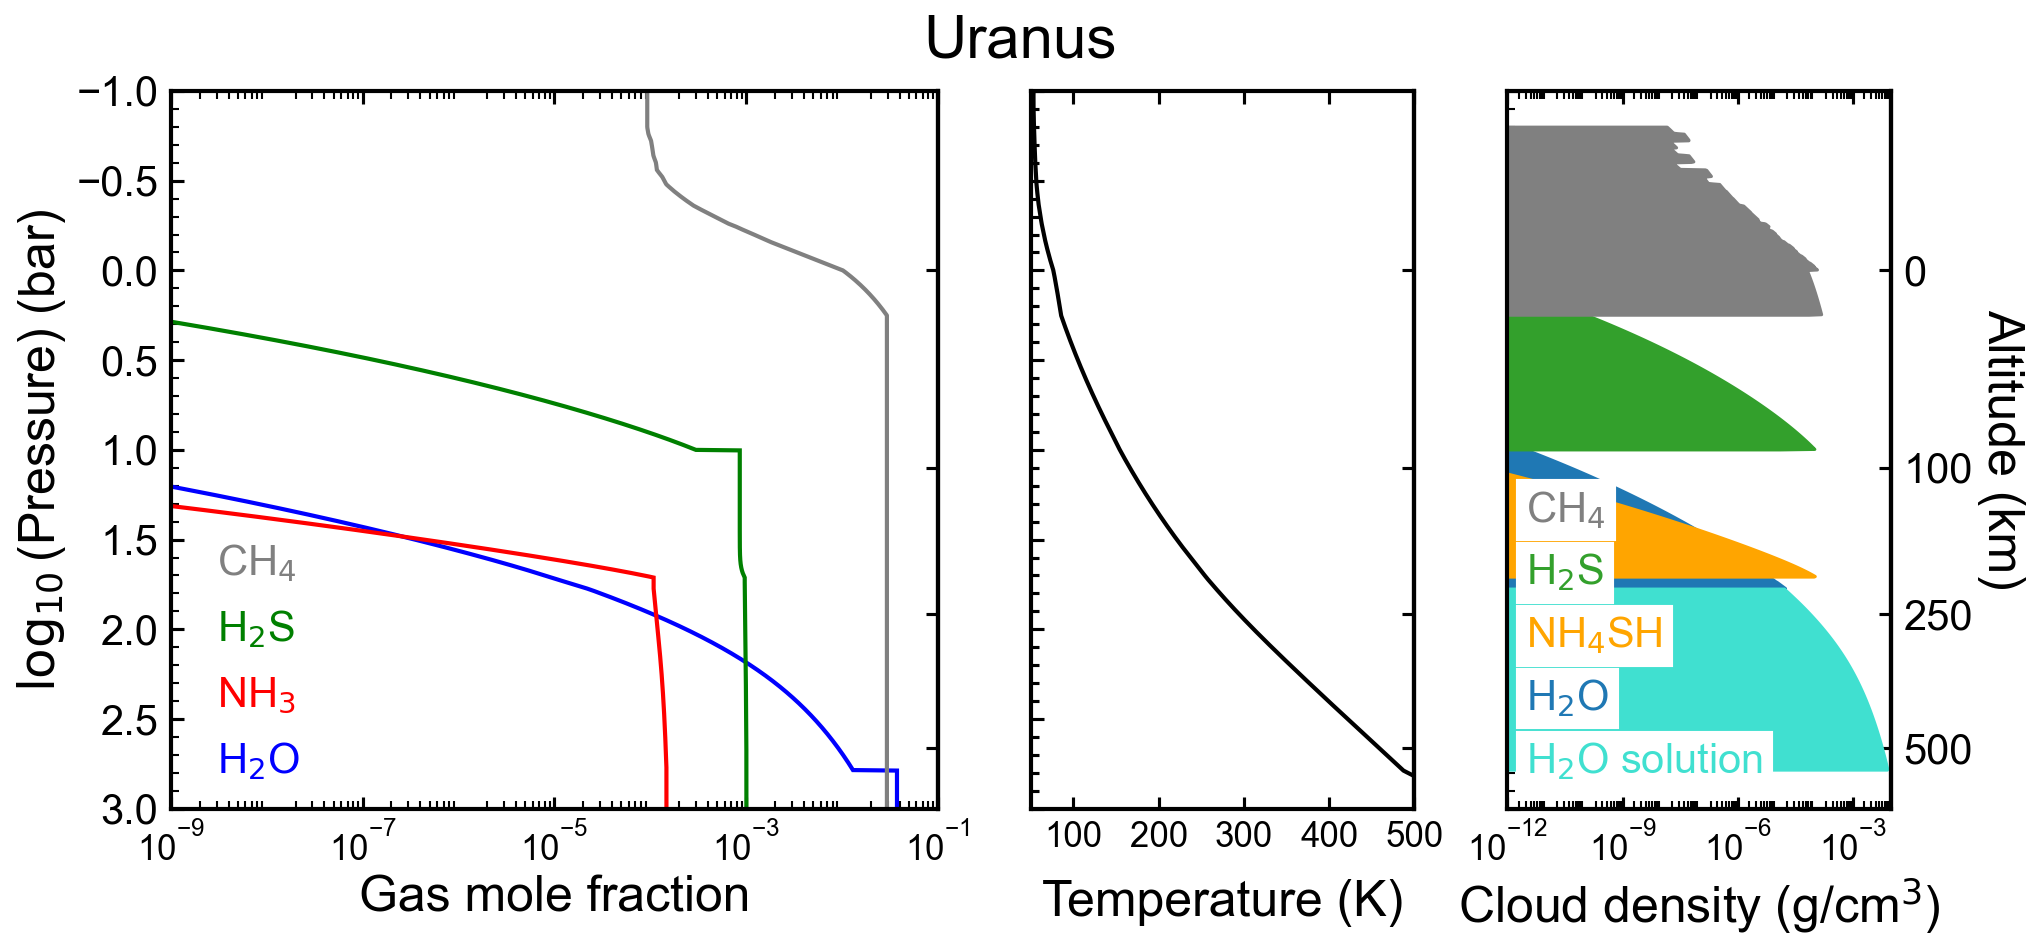

In [34]:
p_grid = np.logspace(2, 9, 2500)
uranus_gravity = 8.87  # m/s2 

# Load RO profile 
data_dir = eccm.__path__[0]
uranus_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/uranus_voyager2_lindal1987.txt'), skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

gases1 = eccm.solar_concentration() 

gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]


result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid'] * 1e-6 
a_h2oliquid = result['aerosol_densities']['H2O']['liquid'] * 1e-6 
a_nh3solid = result['aerosol_densities']['NH3']['solid'] * 1e-6 
a_nh3liquid = result['aerosol_densities']['NH3']['liquid'] * 1e-6 
a_h2ssolid = result['aerosol_densities']['H2S']['solid'] * 1e-6 
a_h2sliquid = result['aerosol_densities']['H2S']['liquid'] * 1e-6 
a_ch4solid = result['aerosol_densities']['CH4']['solid'] * 1e-6 
a_ch4liquid = result['aerosol_densities']['CH4']['liquid'] * 1e-6 
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid'] * 1e-6 
a_nh4sh = result['aerosol_densities']['NH4SH']['solid'] * 1e-6 

def p_to_z(x):
    return np.interp(x, np.log10(pressure_grid / spc.bar)[::-1], altitude_grid[::-1])

def z_to_p(x): 
    return np.interp(x, altitude_grid[::-1], np.log10(pressure_grid / spc.bar)[::-1])


gs = GridSpec(1, 3, width_ratios=[2, 1, 1], height_ratios=[1])


fig = plt.figure(figsize=(14, 7)) 
ax = fig.add_subplot(gs[1]) 
ax.plot(temperature_grid, np.log10(pressure_grid / spc.bar), color='k')
ax.set_xlabel('Temperature (K)', labelpad=12)
ax.set_ylim(-1, 3)
ax.set_xlim(50, 500)
ax.invert_yaxis()
ax.set_xticks([100, 200, 300, 400, 500])
ax.tick_params(axis='x', which='major', labelsize='small')
ax.tick_params(axis='x', which='minor', bottom=False, top=False)
ax.tick_params(right=False, which='both')
ax.yaxis.set_tick_params(labelcolor='none')


secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.yaxis.set_tick_params(labelcolor='none')


ax = fig.add_subplot(gs[0]) 
ax.plot(x_h2o, np.log10(pressure_grid / spc.bar), label='H$_2$O', color='b')
ax.plot(x_nh3, np.log10(pressure_grid / spc.bar), label='NH$_3$', color='r')
ax.plot(x_h2s, np.log10(pressure_grid / spc.bar), label='H$_2$S', color='g')
ax.plot(x_ch4, np.log10(pressure_grid / spc.bar), label='CH$_4$', color='gray')
ax.set_xlabel('Gas mole fraction')
ax.set_ylabel(r'$\log_{10}$(Pressure) (bar)')
ax.tick_params(axis='x', which='major', labelsize='small')
ax.set_xscale('log')
ax.set_xlim(1e-9, 1e-1)
ax.set_ylim(-1, 3)
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.tick_params(bottom=True, top=True, which='minor', width=1)

ax.invert_yaxis()
ax.tick_params(right=False, which='both')
secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.yaxis.set_tick_params(labelcolor='none')
sp = np.linspace(1.7, 2.8, 4)[::-1]
ax.text(3e-9, sp[0], 'H$_2$O', color='b')
ax.text(3e-9, sp[1], 'NH$_3$', color='r')
ax.text(3e-9, sp[2], 'H$_2$S', color='g')
ax.text(3e-9, sp[3], 'CH$_4$', color='gray')


paired_cmap = plt.get_cmap('Paired')

ax = fig.add_subplot(gs[2]) 
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2osolid, label='H$_2$O solid', color=paired_cmap(1))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2oliquid, label='H$_2$O liquid', color=paired_cmap(0))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2osolution, label='H$_2$O solution', color='turquoise')
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2ssolid, label='H$_2$S solid', color=paired_cmap(3))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_h2sliquid, label='H$_2$S liquid', color=paired_cmap(2))
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_ch4solid, label='CH$_4$ solid', color='gray')
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_ch4liquid, label='CH$_4$ liquid', color='k')
ax.fill_betweenx(np.log10(pressure_grid / spc.bar), 0., a_nh4sh, label='NH4SH', color='orange')
ax.set_xlabel('Cloud density (g/cm$^3$)')
ax.set_xscale('log')
ax.set_ylim(-1, 3)
ax.set_xlim(1e-12, 1e-2)
ax.invert_yaxis()
ax.set_xticks([1e-12, 1e-9, 1e-6, 1e-3])
ax.tick_params(right=False, which='both')
ax.yaxis.set_tick_params(labelcolor='none')
ax.tick_params(axis='x', which='major', labelsize='small')
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.tick_params(bottom=True, top=True, which='minor', width=1)
sp = np.linspace(1.4, 2.8, 5)[::-1]
ax.text(3e-12, sp[0], 'H$_2$O solution', color='turquoise', backgroundcolor='white', zorder=5)
ax.text(3e-12, sp[1], 'H$_2$O', color=paired_cmap(1), backgroundcolor='white', zorder=4)
ax.text(3e-12, sp[2], 'NH$_4$SH', color='orange', backgroundcolor='white', zorder=3)
ax.text(3e-12, sp[3], 'H$_2$S', color=paired_cmap(3), backgroundcolor='white', zorder=2)
ax.text(3e-12, sp[4], 'CH$_4$', color='gray', backgroundcolor='white', zorder=1)


secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.yaxis.set_major_formatter(ticker.ScalarFormatter())
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.set_ylabel('Altitude (km)', rotation=-90, labelpad=25) 

fig.suptitle('Uranus', y=0.92, fontsize='x-large')
fig.tight_layout(w_pad=-2) 
fig.savefig('uranus_eccm.pdf')



## Emission and angular spectrum, atmospheric weighting functions 

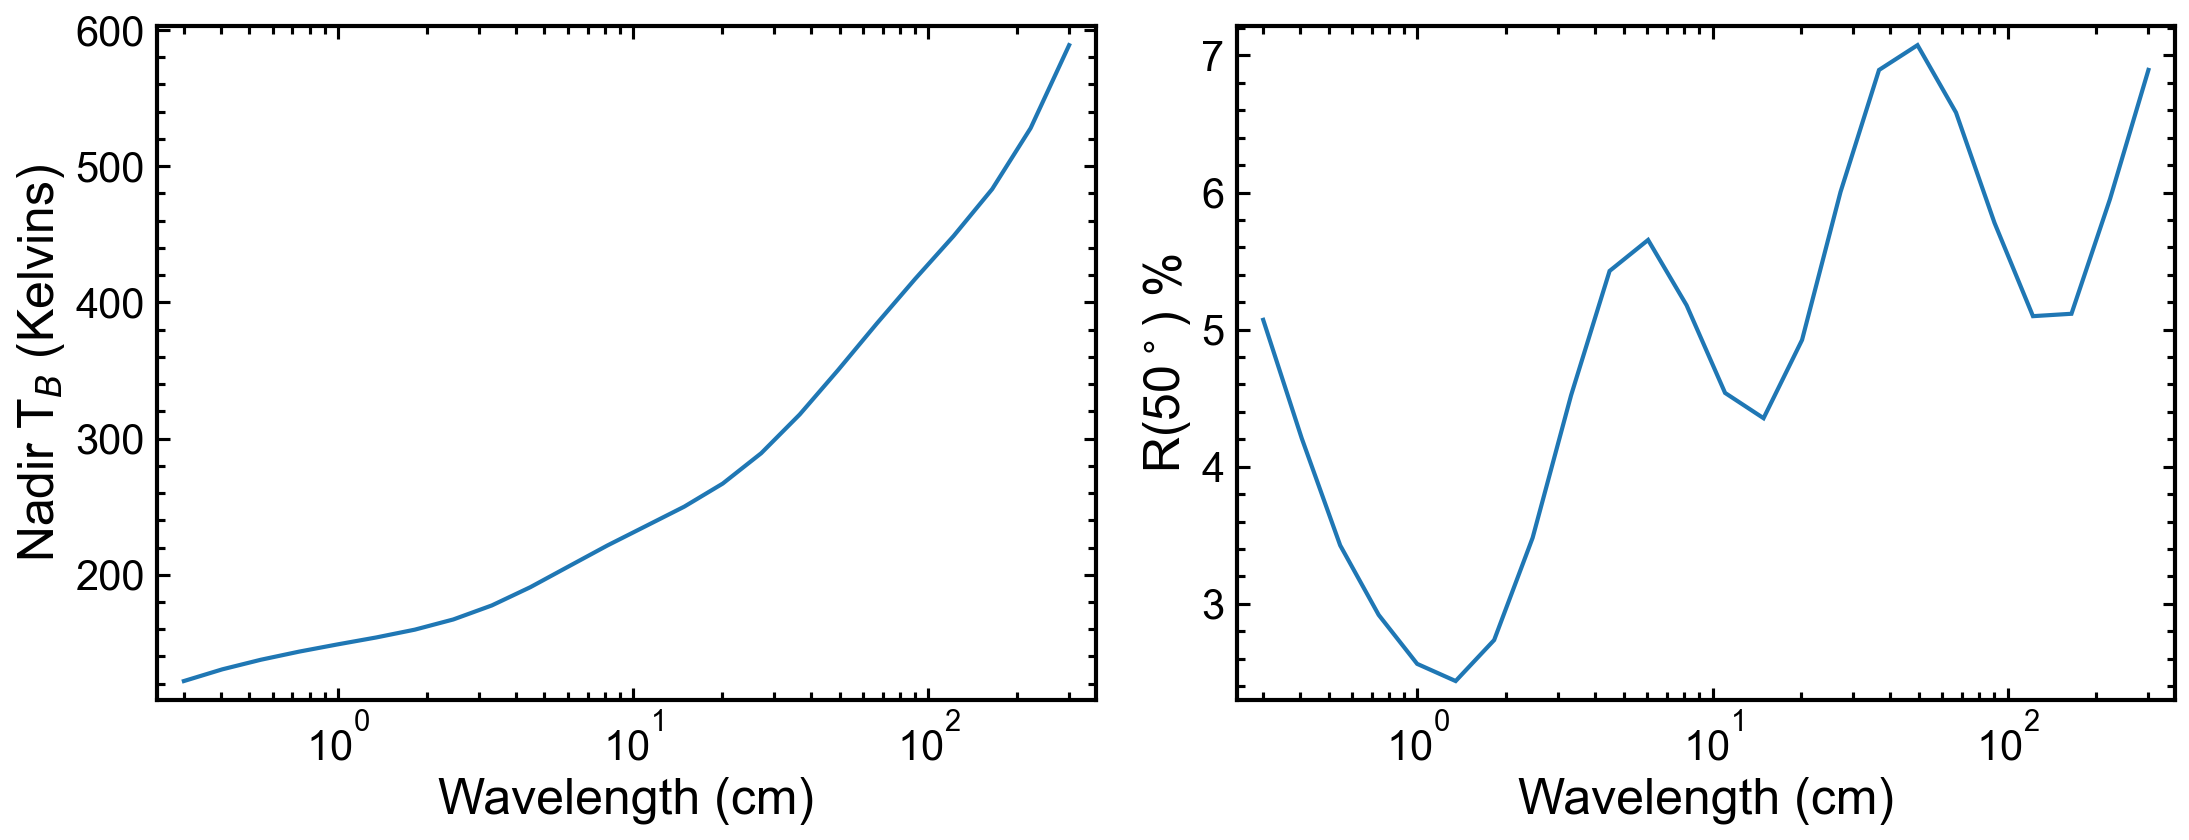

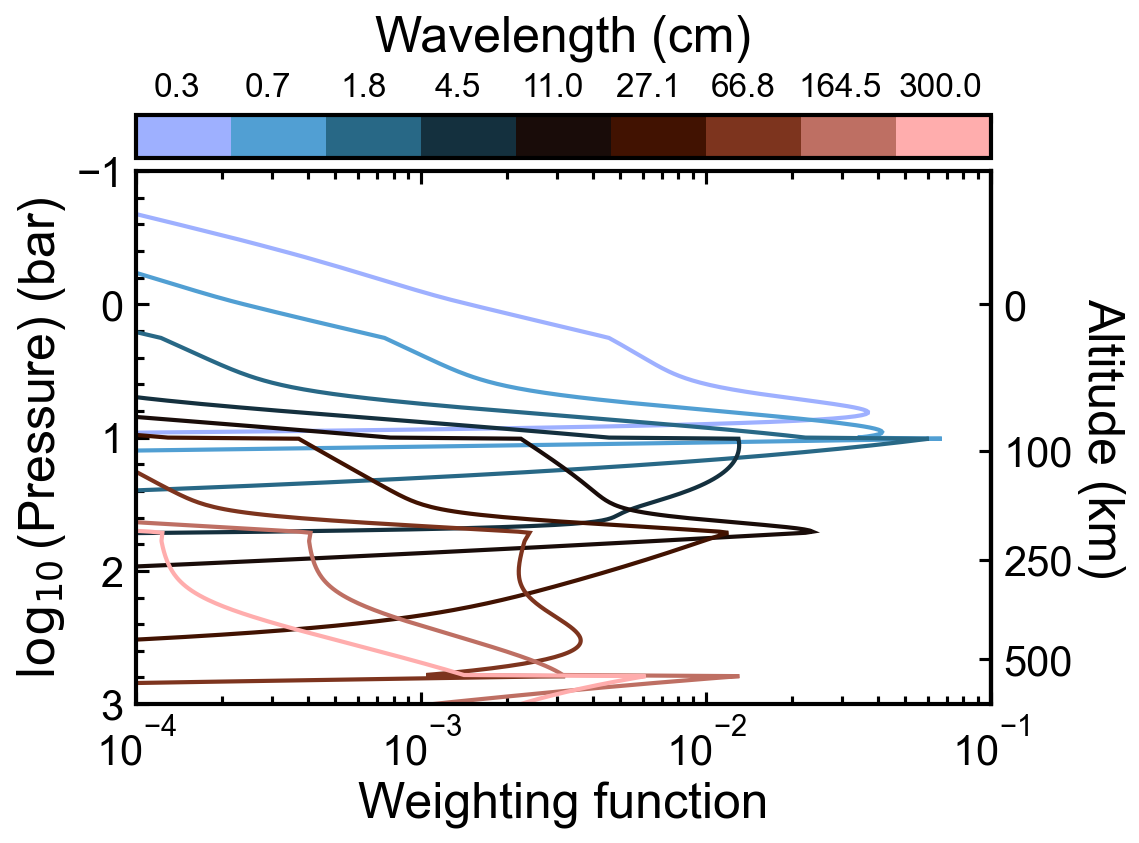

In [5]:
planet_radius = 25559  # Uranus

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
freq_ghz = spc.c / 1e9 / np.logspace(np.log10(3e-3), np.log10(3), 24)
freq_ghz = np.append(freq_ghz, spc.c / 1e9 / 3)  # Staple 3m at the end 
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 

ax1.plot(wave_cm, spec1)
ax2.plot(wave_cm, R50)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('Nadir T$_B$ (Kelvins)')
ax2.set_ylabel(r'R(50$^\circ$) %')
ax1.set_xscale('log')
ax2.set_xscale('log')
fig.tight_layout()


fig = plt.figure() 
ax = fig.add_subplot(1, 1, 1) 

# Colormap setup
freqs = freq_ghz[::3]  # Only using every third frequency
waves = wave_cm[::3]
n_colors = len(freqs)
cmap = plt.get_cmap('berlin', n_colors)  # Discrete version of colormap

edges = np.concatenate([np.array([np.min(waves) - 0.01]), 
                (waves[:-1] + waves[1:]) / 2, 
                np.array([np.max(waves) + 0.01])]) 
norm = colors.BoundaryNorm(edges, ncolors=n_colors)

for i, wup in enumerate(weight_up):
    if not i % 3:
        wave = wave_cm[i]
        color = cmap(norm(wave))
        ax.semilogx(wup, np.log10(pressure_grid[slc] / spc.bar), color=color)

ax.set_xlabel('Weighting function')
ax.set_ylabel(r'$\log_{10}$(Pressure) (bar)')
ax.set_ylim(-1, 3)
ax.set_xlim(1e-4, 1e-1)
ax.invert_yaxis()
ax.tick_params(right=False, which='both')
secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.yaxis.set_major_formatter(ticker.ScalarFormatter())
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')
secax.set_ylabel('Altitude (km)', rotation=-90, labelpad=25) 


# Colorbar 
tick_locs = np.sqrt(edges[:-1] * edges[1:])
tick_labels = ['{:.1f}'.format(f) for f in waves]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation='horizontal', location='top', pad=0.02,
    boundaries=edges, ticks=tick_locs
)
cbar.set_label('Wavelength (cm)', labelpad=10)
cbar.ax.set_xticklabels(tick_labels, size=16)

fig.tight_layout() 
fig.savefig('uranus_weightfunction.pdf')



